<div align='center'>
    <h1>Tugas Besar Dasar Kecerdasan Artifisial</h1>
    <h2>Kelas &nbsp;: IF 04-03</h2>

| **Nama** | **NIM** |
|---|---|
| A’ilah Nailul Fa’izah | 103072400042 |
| Nayyara Aurelia Putri | 103072400097 |
| Jingga Jil Carissa | 103072400121 |
| Bethari Nevyta Amaries | 103072430016 |

</div>


### Soal 1 `(Total Bobot: 100 Poin)`

---

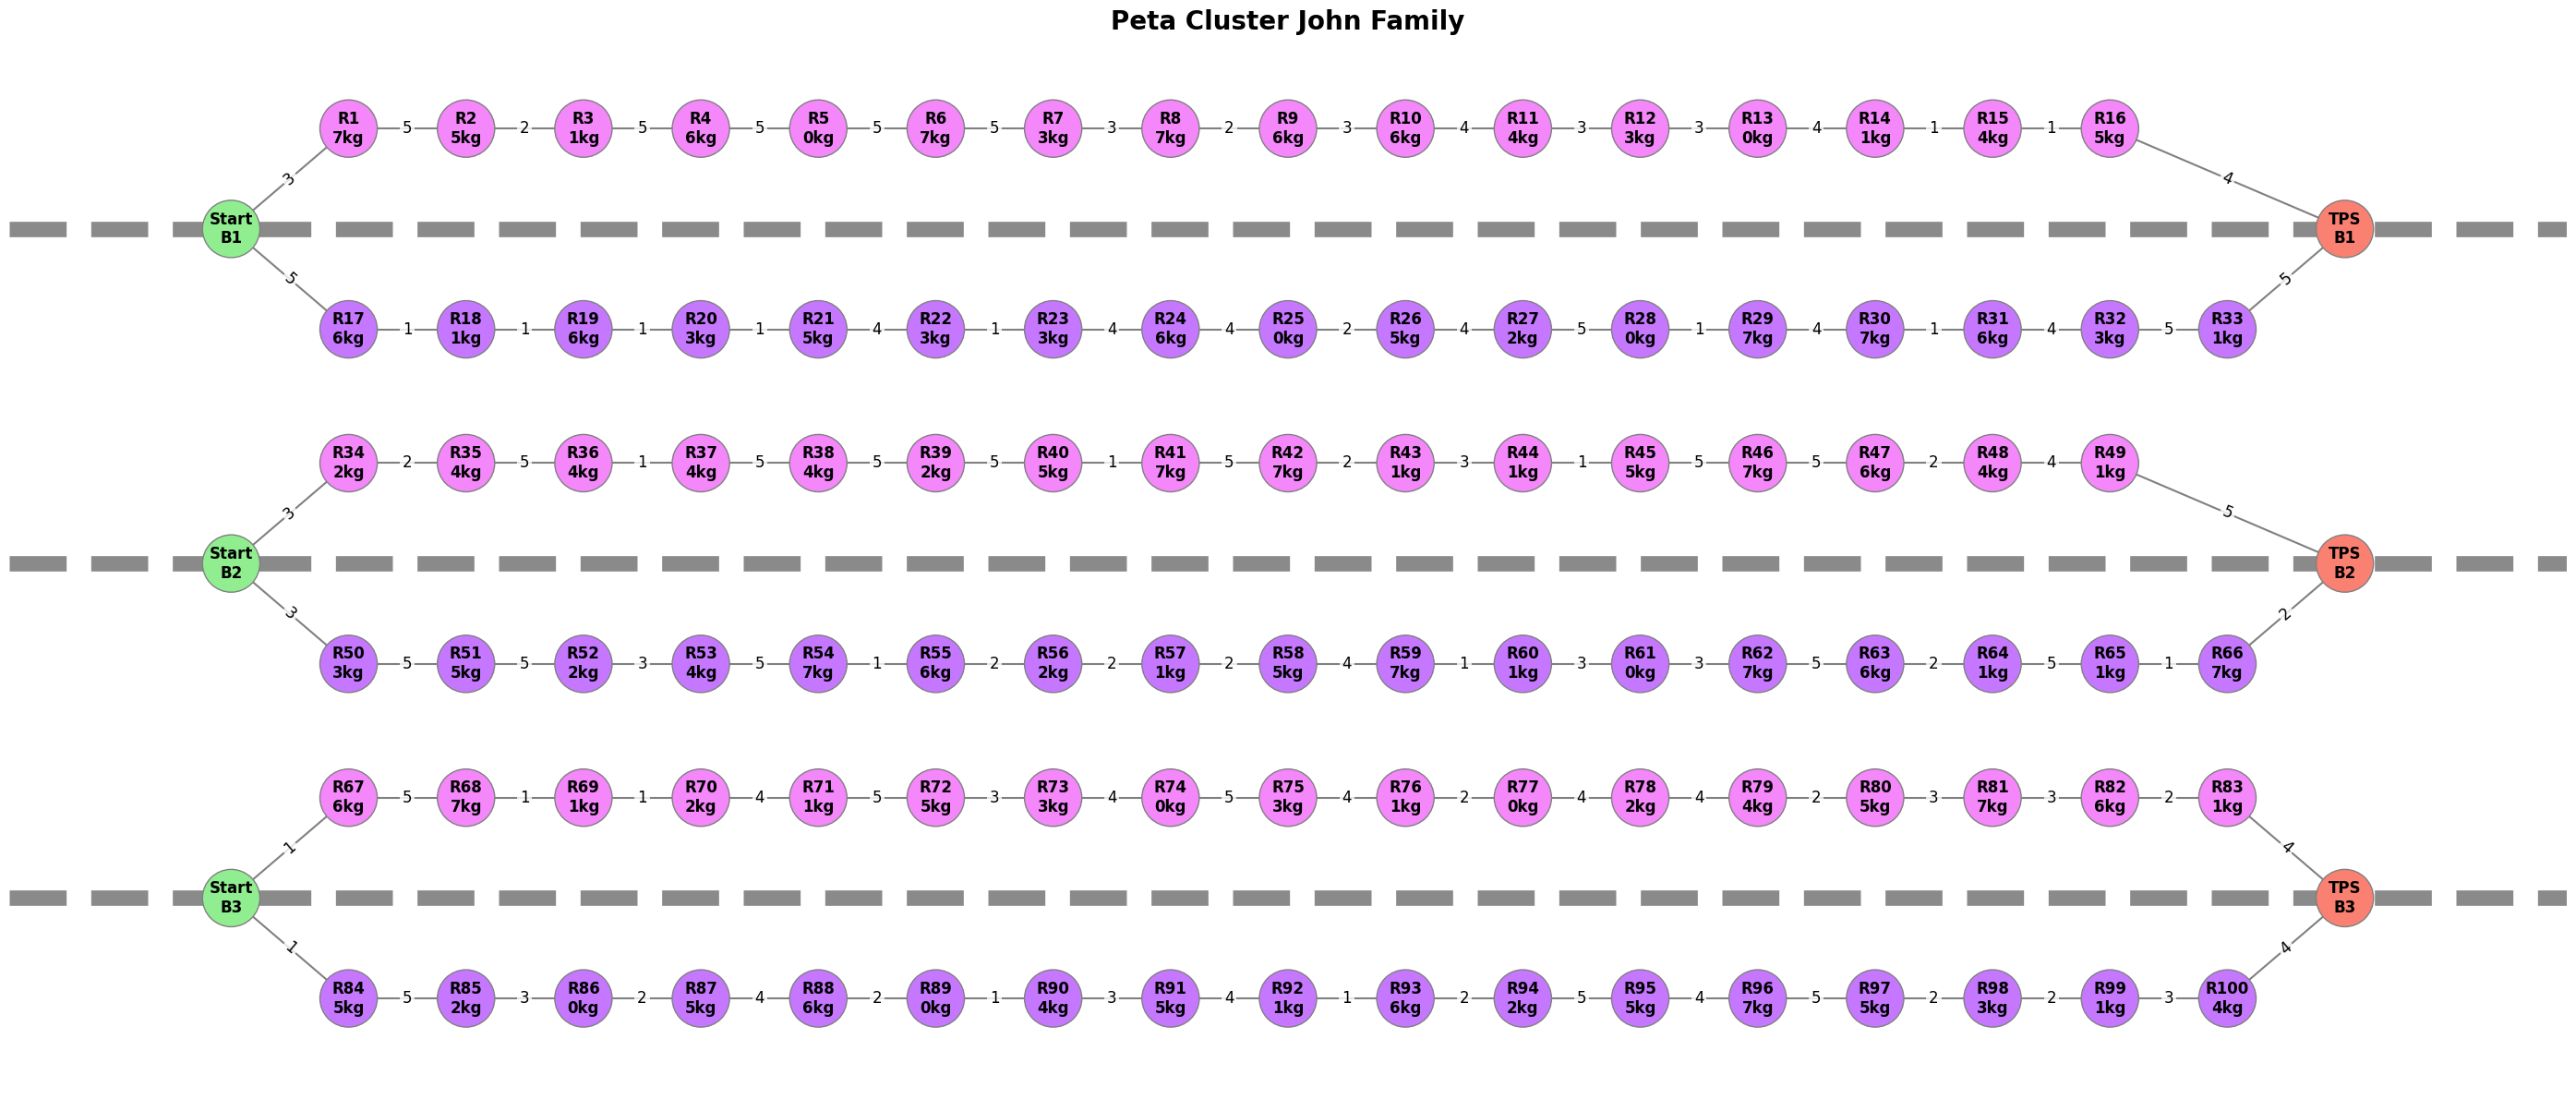


      SIMULASI PENGANGKUTAN (100 RUMAH)      

-----------------------------------------------------------------
 LAPORAN BLOK 1 (URUTAN WAKTU/JARAK) 
-----------------------------------------------------------------
[Jalur Atas ] 🗑️ Gerobak 1A ambil 7kg di R1. (Total: 7/15kg)
[Jalur Bawah] 🗑️ Gerobak 1B ambil 6kg di R17. (Total: 6/15kg)
[Jalur Bawah] 🗑️ Gerobak 1B ambil 1kg di R18. (Total: 7/15kg)
[Jalur Bawah] 🗑️ Gerobak 1B ambil 6kg di R19. (Total: 13/15kg)
[Jalur Bawah] 💡 HEURISTIK! Gerobak 1B isi 13kg di R19. Minta Truk datang sebelum jalan ke R20.
[Jalur Atas ] 🗑️ Gerobak 1A ambil 5kg di R2. (Total: 12/15kg)
[Jalur Atas ] 💡 HEURISTIK! Gerobak 1A isi 12kg di R2. Minta Truk datang sebelum jalan ke R3.
[Jalur Bawah] 🗑️ Gerobak 1B ambil 3kg di R20. (Total: 3/15kg)
[Jalur Bawah] 🗑️ Gerobak 1B ambil 5kg di R21. (Total: 8/15kg)
[Jalur Atas ] 🗑️ Gerobak 1A ambil 1kg di R3. (Total: 1/15kg)
[Jalur Bawah] 🗑️ Gerobak 1B ambil 3kg di R22. (Total: 11/15kg)
[Jalur Bawah] 💡 HEURISTIK! Gerobak 1

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# 1. INISIALISASI ATURAN, KAPASITAS, DAN HEURISTIK
# =====================================================================
kapasitas_gerobak = 15
kapasitas_truk = 200

# [HEURISTIK] : Jika muatan sudah >= 11kg, gerobak akan panggil truk sebelum jalan agar tidak Stuck.
batas_heuristik = 11 

# Konfigurasi 3 Blok (100 Rumah dibagi 2 jalur: Atas dan Bawah)
blok_config = [
    {'id': 1, 'top_range': range(1, 17),  'bot_range': range(17, 34),  'y_pos': 9},
    {'id': 2, 'top_range': range(34, 50), 'bot_range': range(50, 67),  'y_pos': 5},
    {'id': 3, 'top_range': range(67, 84), 'bot_range': range(84, 101), 'y_pos': 1}
]

G = nx.Graph()
pos = {}
node_labels = {}
node_colors = []

# 2. MEMBUAT PETA DESA
# =====================================================================
for blok in blok_config:
    s_node = f"Start_B{blok['id']}"
    t_node = f"TPS_B{blok['id']}"
    
    # Membuat Titik Start
    G.add_node(s_node, type='start', sampah=0)
    pos[s_node] = (0, blok['y_pos'])
    node_labels[s_node] = f"Start\nB{blok['id']}"
    
    # Menyusun rumah berjejer
    def bangun_jalur(range_rumah, offset_y, tipe_jalur):
        titik_sebelumnya = s_node
        max_x = 0
        for idx, i in enumerate(range_rumah):
            nama_rumah = f"R{i}"
            berat_sampah = random.randint(0, 7) # Sampah 0-7 kg
            jarak_jalan = random.randint(1, 5)  # Jarak 1-5 satuan
            
            G.add_node(nama_rumah, type=tipe_jalur, sampah=berat_sampah)
            G.add_edge(titik_sebelumnya, nama_rumah, weight=jarak_jalan)
            
            x_pos = (idx + 1) * 3
            pos[nama_rumah] = (x_pos, blok['y_pos'] + offset_y)
            node_labels[nama_rumah] = f"{nama_rumah}\n{berat_sampah}kg"
            
            titik_sebelumnya = nama_rumah
            max_x = max(max_x, x_pos)
            
        # Penghubung rumah terakhir ke TPS
        jarak_ke_tps = random.randint(1, 5)
        G.add_edge(titik_sebelumnya, t_node, weight=jarak_ke_tps)
        return max_x

    # Eksekusi membuat jalur atas dan bawah
    x_terjauh_atas = bangun_jalur(blok['top_range'], 1.2, 'atas')
    x_terjauh_bawah = bangun_jalur(blok['bot_range'], -1.2, 'bawah')
    
    # Membuat Titik TPS
    final_x = max(x_terjauh_atas, x_terjauh_bawah) + 3
    G.add_node(t_node, type='tps', sampah=0)
    pos[t_node] = (final_x, blok['y_pos'])
    node_labels[t_node] = f"TPS\nB{blok['id']}"


# 3. VISUALISASI PETA DENGAN MATPLOTLIB
# =====================================================================
for node, data in G.nodes(data=True):
    tipe = data.get('type')
    if tipe == 'start': node_colors.append('#90EE90')     
    elif tipe == 'tps': node_colors.append('#FA8072')     
    elif tipe == 'atas': node_colors.append("#F487FA")    
    elif tipe == 'bawah': node_colors.append("#C578FF")   

plt.figure(figsize=(28, 12))
ax = plt.gca()

# Menggambar jalan aspal (garis putus-putus) untuk Truk
for blok in blok_config:
    ax.axhline(y=blok['y_pos'], color="#8A8A8AFF", linewidth=12, zorder=0, linestyle='--')

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, edgecolors='gray', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=12, font_weight='bold', ax=ax)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_size=12, font_color='black',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2), ax=ax
)

plt.title("Peta Cluster John Family", fontsize=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# 4. FUNGSI SIMULASI & LOGIKA HEURISTIK
# =====================================================================
print("\n" + "="*70)
print("      SIMULASI PENGANGKUTAN (100 RUMAH)      ")
print("="*70)

def jalankan_gerobak(nama_gerobak, nama_truk, rute_nodes, penanda_jalur):
    muatan_g = 0
    muatan_t = 0
    jarak_g = 0
    jarak_t = 0
    events = [] 
    
    for i in range(len(rute_nodes) - 1):
        asal = rute_nodes[i]
        tujuan = rute_nodes[i+1]
        
        jarak = G[asal][tujuan]['weight']
        sampah_di_depan = G.nodes[tujuan]['sampah']
        
        # [HEURISTIK]: Mengecek kondisi sebelum melangkah!
        if muatan_g >= batas_heuristik and "TPS" not in tujuan:
            # Gerobak memprediksi akan stuck, jadi dia panggil truk SEKARANG di posisi 'asal'
            if (jarak_g - jarak_t) > 0: jarak_t += (jarak_g - jarak_t)
            muatan_t += muatan_g
            events.append({
                'jarak': jarak_g,
                'pesan': f"[{penanda_jalur}] 💡 HEURISTIK! {nama_gerobak} isi {muatan_g}kg di {asal}. Minta Truk datang sebelum jalan ke {tujuan}."
            })
            muatan_g = 0 # Gerobak kosong kembali
            
        jarak_g += jarak
        
        # Jika tujuan adalah TPS
        if "TPS" in tujuan:
            muatan_t += muatan_g
            events.append({
                'jarak': jarak_g,
                'pesan': f"[{penanda_jalur}] 🏁 {nama_gerobak} tiba di {tujuan}. Sisa {muatan_g}kg dibuang ke TPS"
            })
            break
            
        # Mengambil sampah di tujuan
        if muatan_g + sampah_di_depan <= kapasitas_gerobak:
            muatan_g += sampah_di_depan
            events.append({
                'jarak': jarak_g,
                'pesan': f"[{penanda_jalur}] 🗑️ {nama_gerobak} ambil {sampah_di_depan}kg di {tujuan}. (Total: {muatan_g}/{kapasitas_gerobak}kg)"
            })
        else:
            # Kondisi Stuck (Fail-safe: Terjadi jika rumah tsb mendadak punya sampah sangat banyak, misal 7kg)
            if (jarak_g - jarak_t) > 0: jarak_t += (jarak_g - jarak_t)
            muatan_t += muatan_g
            events.append({
                'jarak': jarak_g,
                'pesan': f"[{penanda_jalur}] ⚠️ STUCK di {tujuan}! Truk menyusul. Muatan diambil (Isi Truk: {muatan_t}kg)"
            })
            muatan_g = sampah_di_depan 
            
    return jarak_g, jarak_t, muatan_t, events


# 5. LAPORAN
# =====================================================================
grand_total_jarak_gerobak = 0
grand_total_jarak_truk = 0
grand_total_sampah = 0
laporan_detail_gerobak = []
laporan_detail_truk = []

for blok in blok_config:
    print(f"\n" + "-"*65)
    print(f" LAPORAN BLOK {blok['id']} (URUTAN WAKTU/JARAK) ")
    print("-"*65)
    
    s_node, t_node = f"Start_B{blok['id']}", f"TPS_B{blok['id']}"
    nama_truk = f"Truk {blok['id']}"
    nama_g_atas, nama_g_bawah = f"Gerobak {blok['id']}A", f"Gerobak {blok['id']}B"
    
    rute_atas = [s_node] + [f"R{i}" for i in blok['top_range']] + [t_node]
    rute_bawah = [s_node] + [f"R{i}" for i in blok['bot_range']] + [t_node]
    
    jg_A, jt_A, mt_A, events_A = jalankan_gerobak(nama_g_atas, nama_truk, rute_atas, "Jalur Atas ")
    jg_B, jt_B, mt_B, events_B = jalankan_gerobak(nama_g_bawah, nama_truk, rute_bawah, "Jalur Bawah")
    
    # Gabung dan Urutkan
    semua_events = events_A + events_B
    semua_events.sort(key=lambda x: x['jarak'])
    for ev in semua_events: print(ev['pesan'])
        
    jarak_truk_blok = max(jt_A, jt_B)
    total_sampah_blok = mt_A + mt_B
    
    print(f"\n📝 REKAP BLOK {blok['id']} | Total Sampah: {total_sampah_blok} kg | Jarak Truk: {jarak_truk_blok}")
    
    laporan_detail_gerobak.extend([
        {"nama": nama_g_atas, "jarak": jg_A, "sampah": mt_A},
        {"nama": nama_g_bawah, "jarak": jg_B, "sampah": mt_B}
    ])
    laporan_detail_truk.append({"nama": nama_truk, "jarak": jarak_truk_blok, "sampah": total_sampah_blok})
    
    grand_total_jarak_gerobak += (jg_A + jg_B)
    grand_total_jarak_truk += jarak_truk_blok
    grand_total_sampah += total_sampah_blok

print("\n=======================================================")
print("            REPORT PERGERAKAN HARIAN PAK KADES           ")
print("=======================================================")
for g in laporan_detail_gerobak:
    print(f"{g['nama']:12} | Jarak: {g['jarak']:3} | Sampah: {g['sampah']:3} kg")
print("-" * 55)
for t in laporan_detail_truk:
    print(f"{t['nama']:12} | Jarak: {t['jarak']:3} | Total TPS: {t['sampah']:3} kg")
print("=======================================================")
print(f"GRAND TOTAL | Sampah: {grand_total_sampah} kg | Truk: {grand_total_jarak_truk} | Gerobak: {grand_total_jarak_gerobak}")


### Soal 2 `(Total Bobot: 50 Poin)`

---

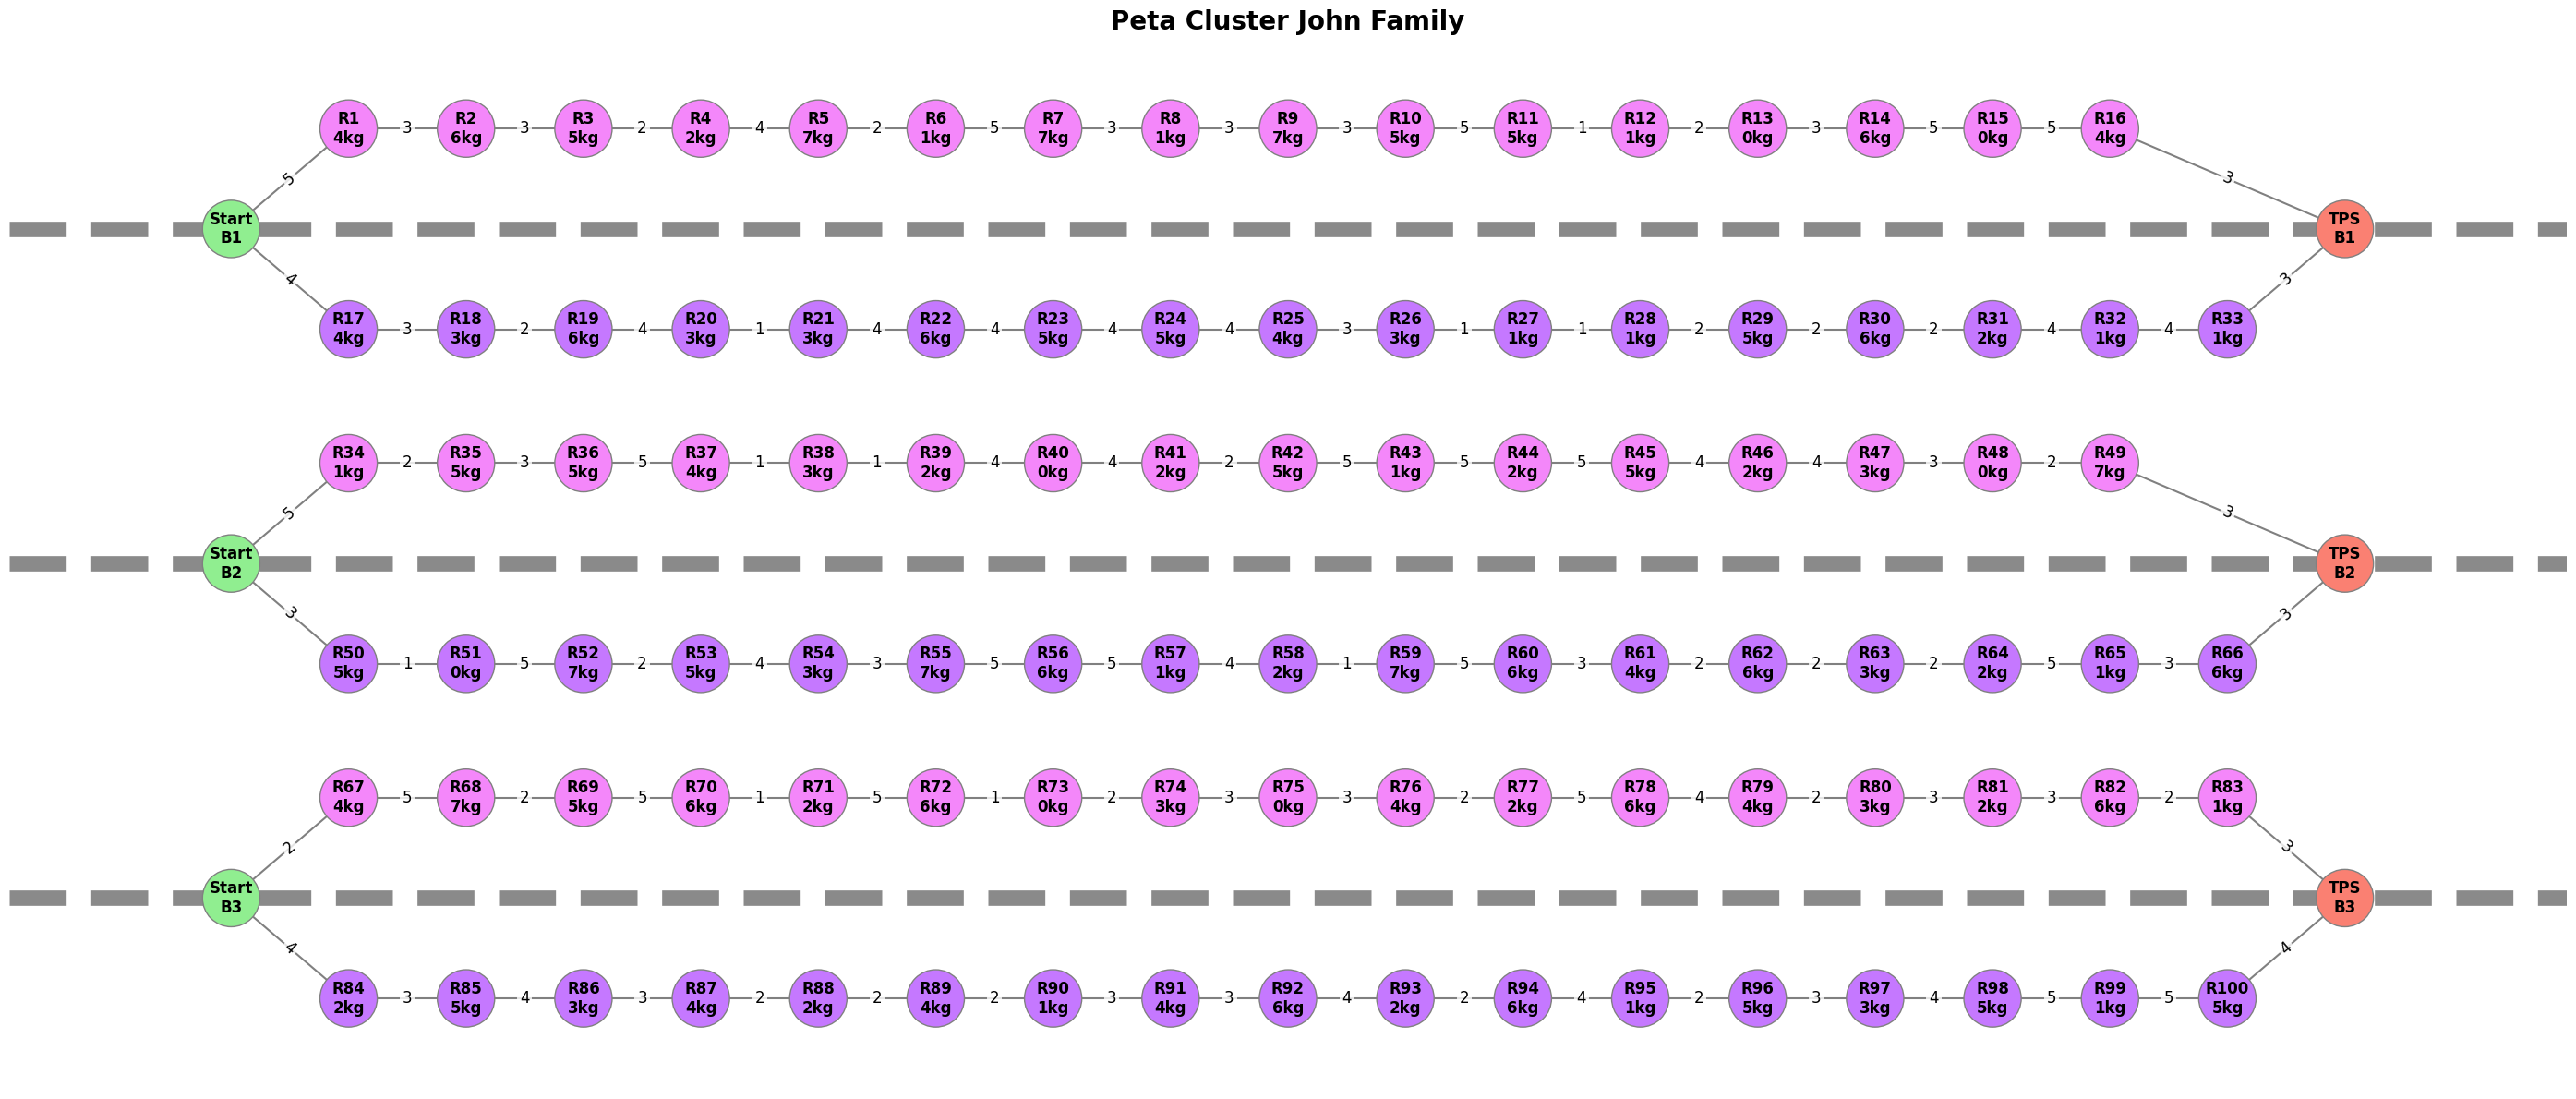


      SIMULASI PENGANGKUTAN (100 RUMAH)      

-----------------------------------------------------------------
 LAPORAN BLOK 1 (URUTAN WAKTU/JARAK) 
-----------------------------------------------------------------
[Jalur Bawah] 🗑️ Gerobak 1B ambil 4kg di R17 (Total: 4/15kg) | Jam 06:20
[Jalur Atas ] 🗑️ Gerobak 1A ambil 4kg di R1 (Total: 4/15kg) | Jam 06:23
[Jalur Bawah] 🗑️ Gerobak 1B ambil 3kg di R18 (Total: 7/15kg) | Jam 06:35
[Jalur Atas ] 🗑️ Gerobak 1A ambil 6kg di R2 (Total: 10/15kg) | Jam 06:44
[Jalur Bawah] 🗑️ Gerobak 1B ambil 6kg di R19 (Total: 13/15kg) | Jam 06:53
[Jalur Atas ] 🗑️ Gerobak 1A ambil 5kg di R3 (Total: 15/15kg) | Jam 07:03
[Jalur Atas ] ⚠️ STUCK di R4! Truk mengambil 15kg
[Jalur Bawah] ⚠️ STUCK di R20! Truk mengambil 13kg
[Jalur Bawah] 🗑️ Gerobak 1B ambil 3kg di R21 (Total: 6/15kg) | Jam 08:21
[Jalur Atas ] 🗑️ Gerobak 1A ambil 7kg di R5 (Total: 9/15kg) | Jam 08:32
[Jalur Bawah] 🗑️ Gerobak 1B ambil 6kg di R22 (Total: 12/15kg) | Jam 08:45
[Jalur Atas ] 🗑️ Gerobak

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# 1. INISIALISASI ATURAN, KAPASITAS, DAN HEURISTIK
# =====================================================================
kapasitas_gerobak = 15
kapasitas_truk = 200

# [HEURISTIK] : Jika muatan sudah >= 11kg, gerobak akan panggil truk sebelum jalan agar tidak Stuck.
batas_heuristik = 11 

# Konfigurasi 3 Blok (100 Rumah dibagi 2 jalur: Atas dan Bawah)
blok_config = [
    {'id': 1, 'top_range': range(1, 17),  'bot_range': range(17, 34),  'y_pos': 9},
    {'id': 2, 'top_range': range(34, 50), 'bot_range': range(50, 67),  'y_pos': 5},
    {'id': 3, 'top_range': range(67, 84), 'bot_range': range(84, 101), 'y_pos': 1}
]

G = nx.Graph()
pos = {}
node_labels = {}
node_colors = []

# 2. MEMBUAT PETA DESA
# =====================================================================
for blok in blok_config:
    s_node = f"Start_B{blok['id']}"
    t_node = f"TPS_B{blok['id']}"
    
    # Membuat Titik Start
    G.add_node(s_node, type='start', sampah=0)
    pos[s_node] = (0, blok['y_pos'])
    node_labels[s_node] = f"Start\nB{blok['id']}"
    
    # Menyusun rumah berjejer
    def bangun_jalur(range_rumah, offset_y, tipe_jalur):
        titik_sebelumnya = s_node
        max_x = 0
        for idx, i in enumerate(range_rumah):
            nama_rumah = f"R{i}"
            berat_sampah = random.randint(0, 7) # Sampah 0-7 kg
            jarak_jalan = random.randint(1, 5)  # Jarak 1-5 satuan
            
            G.add_node(nama_rumah, type=tipe_jalur, sampah=berat_sampah)
            G.add_edge(titik_sebelumnya, nama_rumah, weight=jarak_jalan)
            
            x_pos = (idx + 1) * 3
            pos[nama_rumah] = (x_pos, blok['y_pos'] + offset_y)
            node_labels[nama_rumah] = f"{nama_rumah}\n{berat_sampah}kg"
            
            titik_sebelumnya = nama_rumah
            max_x = max(max_x, x_pos)
            
        # Penghubung rumah terakhir ke TPS
        jarak_ke_tps = random.randint(1, 5)
        G.add_edge(titik_sebelumnya, t_node, weight=jarak_ke_tps)
        return max_x

    # Eksekusi membuat jalur atas dan bawah
    x_terjauh_atas = bangun_jalur(blok['top_range'], 1.2, 'atas')
    x_terjauh_bawah = bangun_jalur(blok['bot_range'], -1.2, 'bawah')
    
    # Membuat Titik TPS
    final_x = max(x_terjauh_atas, x_terjauh_bawah) + 3
    G.add_node(t_node, type='tps', sampah=0)
    pos[t_node] = (final_x, blok['y_pos'])
    node_labels[t_node] = f"TPS\nB{blok['id']}"


# 3. VISUALISASI PETA DENGAN MATPLOTLIB
# =====================================================================
for node, data in G.nodes(data=True):
    tipe = data.get('type')
    if tipe == 'start': node_colors.append('#90EE90')     
    elif tipe == 'tps': node_colors.append('#FA8072')     
    elif tipe == 'atas': node_colors.append("#F487FA")    
    elif tipe == 'bawah': node_colors.append("#C578FF")   

plt.figure(figsize=(28, 12))
ax = plt.gca()

# Menggambar jalan aspal (garis putus-putus) untuk Truk
for blok in blok_config:
    ax.axhline(y=blok['y_pos'], color="#8A8A8AFF", linewidth=12, zorder=0, linestyle='--')

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, edgecolors='gray', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=12, font_weight='bold', ax=ax)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_size=12, font_color='black',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2), ax=ax
)

plt.title("Peta Cluster John Family", fontsize=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# 4. FUNGSI SIMULASI & LOGIKA HEURISTIK
# =====================================================================
print("\n" + "="*70)
print("      SIMULASI PENGANGKUTAN (100 RUMAH)      ")
print("="*70)

def jalankan_gerobak(nama_gerobak, nama_truk, rute_nodes, penanda_jalur):

    muatan_g = 0
    muatan_t = 0

    jarak_g = 0
    jarak_t = 0

    waktu_g = jam_mulai_gerobak
    waktu_t = jam_mulai_truk

    sisa_sampah = 0

    events = []

    for i in range(len(rute_nodes) - 1):

        asal = rute_nodes[i]
        tujuan = rute_nodes[i + 1]

        jarak = G[asal][tujuan]['weight']
        sampah_di_depan = G.nodes[tujuan]['sampah']

        # CEK APAKAH GEROBak MASIH BISA OPERASI
        # ==========================================================
        waktu_perjalanan_g = timedelta(minutes=jarak * 3)

        if waktu_g + waktu_perjalanan_g > jam_selesai_gerobak:
            events.append({
                'jarak': jarak_g,
                'pesan': f"[{penanda_jalur}] ⏰ Operasi gerobak selesai sebelum mencapai {tujuan}"
            })

            sisa_sampah += sampah_di_depan
            continue

        # HEURISTIK PANGGIL TRUK
        # ==========================================================
        if muatan_g >= batas_heuristik and "TPS" not in tujuan:

            # Tunggu truk mulai operasi
            if waktu_g < jam_mulai_truk:
                waktu_g = jam_mulai_truk

            # Loading gerobak -> truk
            waktu_loading = timedelta(minutes=muatan_g * 2)

            if waktu_t + waktu_loading <= jam_selesai_truk:

                # Truk bergerak menuju posisi gerobak
                if jarak_g > jarak_t:
                    jarak_t += (jarak_g - jarak_t)

                muatan_t += muatan_g
                waktu_t += waktu_loading

        # GEROBak BERJALAN
        # ==========================================================
        jarak_g += jarak
        waktu_g += waktu_perjalanan_g

        # JIKA TUJUAN TPS
        # ==========================================================
        if "TPS" in tujuan:

            waktu_loading_tps = timedelta(minutes=(muatan_g / 10) * 2) #tambahan
            if waktu_t + waktu_loading_tps <= jam_selesai_truk:

                muatan_t += muatan_g
                waktu_t += waktu_loading_tps

                events.append({
                    'jarak': jarak_g,
                    'pesan': f"[{penanda_jalur}] 🏁 {nama_gerobak} tiba di {tujuan} | Buang {muatan_g}kg | Jam {format_jam(waktu_g)}"
                })

            else:
                sisa_sampah += muatan_g

            break

        # AMBIL SAMPAH DI RUMAH
        # ==========================================================
        waktu_loading_rumah = timedelta(minutes=sampah_di_depan * 2) #tambahan

        if waktu_g + waktu_loading_rumah > jam_selesai_gerobak:
            sisa_sampah += sampah_di_depan

            events.append({
                'jarak': jarak_g,
                'pesan': f"[{penanda_jalur}] ⏰ Waktu habis saat loading di {tujuan}"
            })

            continue

        # JIKA MUATAN MASIH CUKUP
        # ==========================================================
        if muatan_g + sampah_di_depan <= kapasitas_gerobak:
            muatan_g += sampah_di_depan
            waktu_g += waktu_loading_rumah #tambahan

            events.append({
                'jarak': jarak_g,
                'pesan': (
                    f"[{penanda_jalur}] 🗑️ {nama_gerobak} ambil "
                    f"{sampah_di_depan}kg di {tujuan} "
                    f"(Total: {muatan_g}/{kapasitas_gerobak}kg)"
                    f" | Jam {format_jam(waktu_g)}"
                )
            })

        else:

            # KONDISI STUCK -
            # ======================================================
            waktu_loading_truk = timedelta(minutes=muatan_g * 2) #tambahan

            if waktu_t + waktu_loading_truk <= jam_selesai_truk:
                muatan_t += muatan_g
                waktu_t += waktu_loading_truk 

                events.append({
                    'jarak': jarak_g,
                    'pesan': (
                        f"[{penanda_jalur}] ⚠️ STUCK di {tujuan}! "
                        f"Truk mengambil {muatan_g}kg"
                    )
                })

                muatan_g = sampah_di_depan

            else:
                sisa_sampah += sampah_di_depan

    # HASIL AKHIR
    # ==============================================================

    total_menit_gerobak = int((waktu_g - jam_mulai_gerobak).total_seconds() / 60)
    total_menit_truk = int((waktu_t - jam_mulai_truk).total_seconds() / 60)

    return (jarak_g, jarak_t, muatan_t, events, total_menit_gerobak, total_menit_truk, sisa_sampah, muatan_g)

# 4A. KONVERSI WAKTU OPERASIONAL - tambahan soal 2 
# =====================================================================

from datetime import datetime, timedelta

# jam Operasional
jam_mulai_gerobak = datetime.strptime("06:00", "%H:%M")
jam_selesai_gerobak = datetime.strptime("15:00", "%H:%M")

jam_mulai_truk = datetime.strptime("08:00", "%H:%M")
jam_selesai_truk = datetime.strptime("17:00", "%H:%M")

# mengonversi menit ke format jam
def format_jam(waktu):
    return waktu.strftime("%H:%M")


# 5. LAPORAN
# =====================================================================
grand_total_jarak_gerobak = 0
grand_total_jarak_truk = 0
grand_total_sampah = 0
laporan_detail_gerobak = []
laporan_detail_truk = []

for blok in blok_config:
    print(f"\n" + "-"*65)
    print(f" LAPORAN BLOK {blok['id']} (URUTAN WAKTU/JARAK) ")
    print("-"*65)
    
    s_node, t_node = f"Start_B{blok['id']}", f"TPS_B{blok['id']}"
    nama_truk = f"Truk {blok['id']}"
    nama_g_atas, nama_g_bawah = f"Gerobak {blok['id']}A", f"Gerobak {blok['id']}B"
    
    rute_atas = [s_node] + [f"R{i}" for i in blok['top_range']] + [t_node]
    rute_bawah = [s_node] + [f"R{i}" for i in blok['bot_range']] + [t_node]
    
    jg_A, jt_A, mt_A, events_A, waktu_gA, waktu_tA, sisa_A, sisa_muatan_A = jalankan_gerobak(
    nama_g_atas, nama_truk, rute_atas, "Jalur Atas ")
    jg_B, jt_B, mt_B, events_B, waktu_gB, waktu_tB, sisa_B, sisa_muatan_B = jalankan_gerobak(
    nama_g_bawah, nama_truk, rute_bawah, "Jalur Bawah")
    
    # Gabung dan Urutkan
    semua_events = events_A + events_B
    semua_events.sort(key=lambda x: x['jarak'])
    for ev in semua_events: print(ev['pesan'])
        
    jarak_truk_blok = max(jt_A, jt_B)
    total_sampah_blok = mt_A + mt_B
    
    print(f"\n📝 REKAP BLOK {blok['id']} | Total Sampah: {total_sampah_blok} kg | Jarak Truk: {jarak_truk_blok}")

    print(f"⏱️ Waktu Gerobak Atas  : {waktu_gA} menit")
    print(f"⏱️ Waktu Gerobak Bawah : {waktu_gB} menit")
    print(f"🚛 Waktu Operasi Truk : {max(waktu_tA, waktu_tB)} menit")
    print(f"♻️ Sisa Sampah Jalur Atas  : {sisa_A} kg")
    print(f"♻️ Sisa Sampah Jalur Bawah : {sisa_B} kg")
    print(f"🧺 Sisa Muatan Gerobak Atas  : {sisa_muatan_A} kg")
    print(f"🧺 Sisa Muatan Gerobak Bawah : {sisa_muatan_B} kg")
    
    laporan_detail_gerobak.extend([
        {"nama": nama_g_atas, "jarak": jg_A, "sampah": mt_A},
        {"nama": nama_g_bawah, "jarak": jg_B, "sampah": mt_B}
    ])
    laporan_detail_truk.append({"nama": nama_truk, "jarak": jarak_truk_blok, "sampah": total_sampah_blok})
    
    grand_total_jarak_gerobak += (jg_A + jg_B)
    grand_total_jarak_truk += jarak_truk_blok
    grand_total_sampah += total_sampah_blok

print("\n=======================================================")
print("            REPORT PERGERAKAN HARIAN PAK KADES           ")
print("=======================================================")
for g in laporan_detail_gerobak:
    print(f"{g['nama']:12} | Jarak: {g['jarak']:3} | Sampah: {g['sampah']:3} kg")
print("-" * 55)
for t in laporan_detail_truk:
    print(f"{t['nama']:12} | Jarak: {t['jarak']:3} | Total TPS: {t['sampah']:3} kg")
print("=======================================================")
print(f"GRAND TOTAL | Sampah: {grand_total_sampah} kg | Truk: {grand_total_jarak_truk} | Gerobak: {grand_total_jarak_gerobak}")
